# Initial Robustness and Trustworthiness Checks for RUL Prediction

This notebook performs initial robustness and trustworthiness checks for the best multi-view RUL prediction model. The focus is on evaluating how the MultiViewGRUFusion model behaves under noisy inputs, missing or masked views, random feature masking, and different RUL ranges. These checks are intended as model-level trustworthiness evidence, not as full AI governance validation.

The robustness checks are performed on the validation set using controlled perturbations. The goal is to observe model sensitivity to input quality changes. These tests do not prove operational reliability, but they provide initial evidence about model behaviour under imperfect input conditions.

## 1. Imports and Setup

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import load_model

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')


TensorFlow: 2.20.0
GPU available: True


## 1b. Colab Path Setup

Run on Google Colab with T4 GPU. Ensure the following are already on Drive:
- `data/processed/multiview/val_multiview_fd001_window30.npz`
- `data/processed/multiview/val_multiview_meta_fd001_window30.csv`
- `models/multiview/MultiViewGRUFusion_window30_fd001.keras`
- `reports/explainability/multiview_view_masking_explainability_fd001.csv`

In [2]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Dissertation/Project/dissertation-rul-xai'
else:
    BASE = '..'

ARRAY_DIR   = f'{BASE}/data/processed/multiview'
MODEL_DIR   = f'{BASE}/models/multiview'
EXPLAIN_DIR = f'{BASE}/reports/explainability'
METRICS_DIR = f'{BASE}/reports/metrics'
FIG_DIR     = f'{BASE}/reports/figures'
PRED_DIR    = f'{BASE}/reports/predictions'
ROBUST_DIR  = f'{BASE}/reports/robustness'

for d in [METRICS_DIR, FIG_DIR, PRED_DIR, ROBUST_DIR]:
    os.makedirs(d, exist_ok=True)

print('Paths set up.')


Mounted at /content/drive
Paths set up.


## 2. Load Model and Validation Arrays

In [3]:
WINDOW_SIZE = 30

val_npz   = np.load(f'{ARRAY_DIR}/val_multiview_fd001_window{WINDOW_SIZE}.npz')
X_val_seq = val_npz['X_seq']
X_val_der = val_npz['X_derived']
y_val     = val_npz['y']
val_meta  = pd.read_csv(f'{ARRAY_DIR}/val_multiview_meta_fd001_window{WINDOW_SIZE}.csv')

fusion_model = load_model(f'{MODEL_DIR}/MultiViewGRUFusion_window{WINDOW_SIZE}_fd001.keras')

print(f'X_val_seq: {X_val_seq.shape}')
print(f'X_val_der: {X_val_der.shape}')
print(f'y_val:     {y_val.shape}')
print(f'val_meta:  {val_meta.shape}')

assert len(X_val_seq) == len(X_val_der) == len(y_val) == len(val_meta)
assert not np.isnan(X_val_seq).any()
assert not np.isnan(X_val_der).any()
assert not np.isnan(y_val).any()
print('Assertions passed.')


X_val_seq: (3711, 30, 14)
X_val_der: (3711, 43)
y_val:     (3711,)
val_meta:  (3711, 4)
Assertions passed.


## 3. Evaluation and Prediction Helpers

In [4]:
def evaluate_predictions(y_true, y_pred):
    y_pred = np.clip(np.asarray(y_pred).reshape(-1), 0, 125)
    rmse         = np.sqrt(mean_squared_error(y_true, y_pred))
    mae          = mean_absolute_error(y_true, y_pred)
    r2           = r2_score(y_true, y_pred)
    mean_error   = float(np.mean(y_pred - y_true))
    median_error = float(np.median(y_pred - y_true))
    return {
        'rmse':         round(float(rmse), 4),
        'mae':          round(float(mae), 4),
        'r2':           round(float(r2), 4),
        'mean_error':   round(mean_error, 4),
        'median_error': round(median_error, 4),
    }


def predict_fusion(model, X_seq, X_der):
    pred = model.predict([X_seq, X_der], verbose=0).reshape(-1)
    return np.clip(pred, 0, 125)


def add_gaussian_noise(X, noise_std, seed=42):
    rng = np.random.default_rng(seed)
    return X + rng.normal(loc=0.0, scale=noise_std, size=X.shape)


def random_mask(X, mask_rate, seed=42):
    rng = np.random.default_rng(seed)
    X_masked = X.copy()
    X_masked[rng.random(X.shape) < mask_rate] = 0.0
    return X_masked


## 4. Baseline Performance

The baseline condition represents normal validation performance with both input views available and no artificial perturbation.

In [5]:
baseline_pred   = predict_fusion(fusion_model, X_val_seq, X_val_der)
baseline_metrics = evaluate_predictions(y_val, baseline_pred)

print('Baseline metrics:')
for k, v in baseline_metrics.items():
    print(f'  {k}: {v}')

baseline_pred_df              = val_meta.copy()
baseline_pred_df['prediction'] = baseline_pred
baseline_pred_df['error']      = baseline_pred_df['prediction'] - baseline_pred_df['RUL_capped']
baseline_pred_df['abs_error']  = baseline_pred_df['error'].abs()

baseline_pred_df.to_csv(f'{ROBUST_DIR}/baseline_predictions_multiview_fd001.csv', index=False)
print('Baseline predictions saved.')


Baseline metrics:
  rmse: 12.0657
  mae: 8.9406
  r2: 0.9168
  mean_error: -2.2779
  median_error: -1.7065
Baseline predictions saved.


In [6]:
robustness_records = []

robustness_records.append({
    'condition':         'baseline',
    'perturbation_type': 'none',
    'noise_std':         0.0,
    'mask_rate':         float('nan'),
    **baseline_metrics
})


## 5. Sensor Sequence Noise Injection

Sensor sequence noise tests the sensitivity of the model to noisy raw sensor history. Since the inputs are standardized, the noise levels are applied in normalized feature space.

In [7]:
noise_levels = [0.05, 0.10, 0.20]

for noise_std in noise_levels:
    X_seq_noisy = add_gaussian_noise(X_val_seq, noise_std, seed=SEED)
    pred        = predict_fusion(fusion_model, X_seq_noisy, X_val_der)
    metrics     = evaluate_predictions(y_val, pred)

    robustness_records.append({
        'condition':         f'sensor_sequence_noise_{noise_std}',
        'perturbation_type': 'sensor_sequence_noise',
        'noise_std':         noise_std,
        'mask_rate':         float('nan'),
        **metrics
    })
    print(f'  seq noise {noise_std}: RMSE {metrics["rmse"]}')


  seq noise 0.05: RMSE 12.0704
  seq noise 0.1: RMSE 12.0864
  seq noise 0.2: RMSE 12.1026


## 6. Derived Feature Noise Injection

Derived feature noise tests the robustness of the degradation feature view. This is important because Step 7 showed that the derived view is the dominant contributor to the fusion model.

In [8]:
for noise_std in noise_levels:
    X_der_noisy = add_gaussian_noise(X_val_der, noise_std, seed=SEED)
    pred        = predict_fusion(fusion_model, X_val_seq, X_der_noisy)
    metrics     = evaluate_predictions(y_val, pred)

    robustness_records.append({
        'condition':         f'derived_feature_noise_{noise_std}',
        'perturbation_type': 'derived_feature_noise',
        'noise_std':         noise_std,
        'mask_rate':         float('nan'),
        **metrics
    })
    print(f'  der noise {noise_std}: RMSE {metrics["rmse"]}')


  der noise 0.05: RMSE 12.092
  der noise 0.1: RMSE 12.1701
  der noise 0.2: RMSE 12.5102


## 7. Combined View Noise Injection

Combined noise evaluates the model when both input views are perturbed. This is a stronger stress condition than perturbing either view independently.

In [9]:
for noise_std in noise_levels:
    X_seq_noisy = add_gaussian_noise(X_val_seq, noise_std, seed=SEED)
    X_der_noisy = add_gaussian_noise(X_val_der, noise_std, seed=SEED + 1)
    pred        = predict_fusion(fusion_model, X_seq_noisy, X_der_noisy)
    metrics     = evaluate_predictions(y_val, pred)

    robustness_records.append({
        'condition':         f'combined_noise_{noise_std}',
        'perturbation_type': 'combined_noise',
        'noise_std':         noise_std,
        'mask_rate':         float('nan'),
        **metrics
    })
    print(f'  combined noise {noise_std}: RMSE {metrics["rmse"]}')


  combined noise 0.05: RMSE 12.1037
  combined noise 0.1: RMSE 12.2123
  combined noise 0.2: RMSE 12.5906


## 8. Random Feature Masking

Random masking simulates incomplete input values. Since features are standardized, zero masking approximates replacing missing values with the training mean. This is a simple first robustness check and does not represent all real missing-data mechanisms.

In [10]:
mask_rates = [0.10, 0.20, 0.30]

for mask_rate in mask_rates:
    X_seq_masked = random_mask(X_val_seq, mask_rate, seed=SEED)
    pred         = predict_fusion(fusion_model, X_seq_masked, X_val_der)
    metrics      = evaluate_predictions(y_val, pred)

    robustness_records.append({
        'condition':         f'sensor_sequence_random_mask_{mask_rate}',
        'perturbation_type': 'sensor_sequence_random_masking',
        'noise_std':         float('nan'),
        'mask_rate':         mask_rate,
        **metrics
    })
    print(f'  seq mask {mask_rate}: RMSE {metrics["rmse"]}')


  seq mask 0.1: RMSE 12.1588
  seq mask 0.2: RMSE 12.3469
  seq mask 0.3: RMSE 12.5428


In [11]:
for mask_rate in mask_rates:
    X_der_masked = random_mask(X_val_der, mask_rate, seed=SEED)
    pred         = predict_fusion(fusion_model, X_val_seq, X_der_masked)
    metrics      = evaluate_predictions(y_val, pred)

    robustness_records.append({
        'condition':         f'derived_feature_random_mask_{mask_rate}',
        'perturbation_type': 'derived_feature_random_masking',
        'noise_std':         float('nan'),
        'mask_rate':         mask_rate,
        **metrics
    })
    print(f'  der mask {mask_rate}: RMSE {metrics["rmse"]}')


  der mask 0.1: RMSE 13.309
  der mask 0.2: RMSE 15.355
  der mask 0.3: RMSE 17.7557


In [12]:
for mask_rate in mask_rates:
    X_seq_masked = random_mask(X_val_seq, mask_rate, seed=SEED)
    X_der_masked = random_mask(X_val_der, mask_rate, seed=SEED + 1)
    pred         = predict_fusion(fusion_model, X_seq_masked, X_der_masked)
    metrics      = evaluate_predictions(y_val, pred)

    robustness_records.append({
        'condition':         f'combined_random_mask_{mask_rate}',
        'perturbation_type': 'combined_random_masking',
        'noise_std':         float('nan'),
        'mask_rate':         mask_rate,
        **metrics
    })
    print(f'  combined mask {mask_rate}: RMSE {metrics["rmse"]}')


  combined mask 0.1: RMSE 13.7275
  combined mask 0.2: RMSE 16.184
  combined mask 0.3: RMSE 19.0455


## 9. View Masking Results from Step 7

View masking was performed in the explainability analysis (Step 7). Those results are included here as missing-view robustness evidence to provide a complete picture alongside noise and random masking conditions.

In [13]:
view_masking_df = pd.read_csv(
    f'{EXPLAIN_DIR}/multiview_view_masking_explainability_fd001.csv'
)
print(view_masking_df.to_string(index=False))

for _, row in view_masking_df.iterrows():
    if row['condition'] == 'both_views_available':
        continue  # already captured as baseline
    robustness_records.append({
        'condition':         row['condition'],
        'perturbation_type': 'view_masking',
        'noise_std':         float('nan'),
        'mask_rate':         float('nan'),
        'rmse':              row['rmse'],
        'mae':               row['mae'],
        'r2':                row['r2'],
        'mean_error':        float('nan'),
        'median_error':      float('nan'),
    })


             condition                                     description    rmse     mae      r2
  both_views_available Sensor sequence view + derived degradation view 12.0657  8.9406  0.9168
sensor_sequence_masked      Derived degradation view only at inference 15.5505 12.6154  0.8618
   derived_view_masked          Sensor sequence view only at inference 42.5692 36.1661 -0.0354


## 10. Robustness Summary Table

In [14]:
robustness_df = pd.DataFrame(robustness_records)

baseline_rmse = baseline_metrics['rmse']
baseline_mae  = baseline_metrics['mae']

robustness_df['rmse_increase']     = robustness_df['rmse'] - baseline_rmse
robustness_df['rmse_increase_pct'] = (robustness_df['rmse_increase'] / baseline_rmse * 100).round(2)
robustness_df['mae_increase']      = robustness_df['mae'] - baseline_mae
robustness_df['mae_increase_pct']  = (robustness_df['mae_increase'] / baseline_mae * 100).round(2)

robustness_df = robustness_df.sort_values('rmse').reset_index(drop=True)

robustness_df.to_csv(f'{ROBUST_DIR}/robustness_summary_multiview_fd001.csv', index=False)

print(robustness_df[['condition','perturbation_type','rmse','mae','r2','rmse_increase_pct']].to_string(index=False))


                      condition              perturbation_type    rmse     mae      r2  rmse_increase_pct
                       baseline                           none 12.0657  8.9406  0.9168               0.00
     sensor_sequence_noise_0.05          sensor_sequence_noise 12.0704  8.9392  0.9168               0.04
      sensor_sequence_noise_0.1          sensor_sequence_noise 12.0864  8.9483  0.9165               0.17
     derived_feature_noise_0.05          derived_feature_noise 12.0920  8.9650  0.9165               0.22
      sensor_sequence_noise_0.2          sensor_sequence_noise 12.1026  8.9582  0.9163               0.31
            combined_noise_0.05                 combined_noise 12.1037  8.9412  0.9163               0.31
sensor_sequence_random_mask_0.1 sensor_sequence_random_masking 12.1588  9.0857  0.9155               0.77
      derived_feature_noise_0.1          derived_feature_noise 12.1701  9.0166  0.9154               0.87
             combined_noise_0.1               

## 11. Robustness Comparison Plot

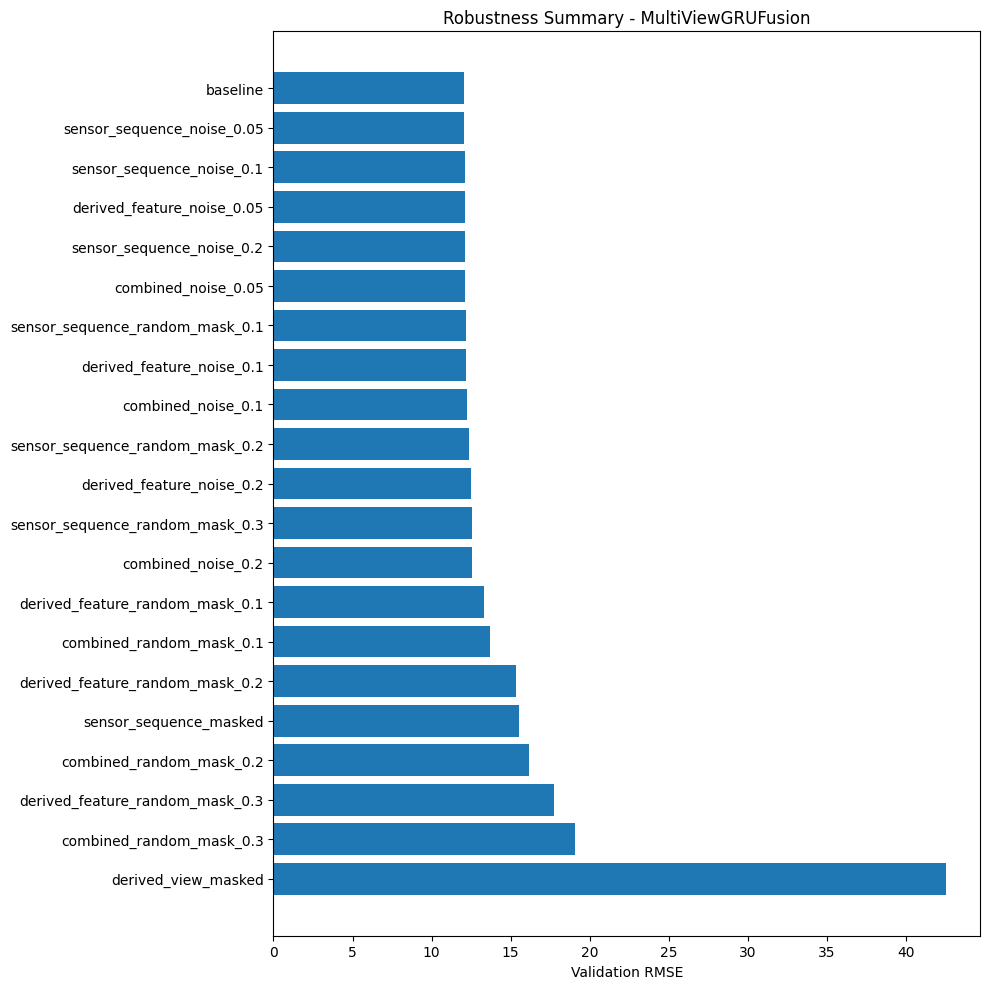

In [15]:
selected_conditions = [
    'baseline',
    'sensor_sequence_noise_0.05',
    'sensor_sequence_noise_0.1',
    'sensor_sequence_noise_0.2',
    'derived_feature_noise_0.05',
    'derived_feature_noise_0.1',
    'derived_feature_noise_0.2',
    'combined_noise_0.05',
    'combined_noise_0.1',
    'combined_noise_0.2',
    'sensor_sequence_random_mask_0.1',
    'sensor_sequence_random_mask_0.2',
    'sensor_sequence_random_mask_0.3',
    'derived_feature_random_mask_0.1',
    'derived_feature_random_mask_0.2',
    'derived_feature_random_mask_0.3',
    'combined_random_mask_0.1',
    'combined_random_mask_0.2',
    'combined_random_mask_0.3',
    'sensor_sequence_masked',
    'derived_view_masked',
]

plot_df = robustness_df[
    robustness_df['condition'].isin(selected_conditions)
].sort_values('rmse')

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(plot_df['condition'], plot_df['rmse'])
ax.set_xlabel('Validation RMSE')
ax.set_title('Robustness Summary - MultiViewGRUFusion')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/robustness_summary_rmse_multiview_fd001.png', dpi=300)
plt.show()


## 12. RUL Range-wise Error Analysis

RUL range-wise analysis checks whether model error differs between near-failure, mid-degradation and early/capped RUL regions. This is important for predictive maintenance because near-failure predictions are often more operationally critical.

In [16]:
rul_error_df = baseline_pred_df.copy()
rul_error_df['rul_range'] = pd.cut(
    rul_error_df['RUL_capped'],
    bins=[-1, 30, 80, 125],
    labels=['near_failure_0_30', 'mid_degradation_31_80', 'early_or_capped_81_125']
)

range_metrics = []
for range_name, group in rul_error_df.groupby('rul_range', observed=True):
    m = evaluate_predictions(group['RUL_capped'], group['prediction'])
    range_metrics.append({'rul_range': range_name, 'sample_count': len(group), **m})

range_metrics_df = pd.DataFrame(range_metrics)
range_metrics_df.to_csv(f'{ROBUST_DIR}/rul_range_error_analysis_multiview_fd001.csv', index=False)
print(range_metrics_df.to_string(index=False))


             rul_range  sample_count    rmse     mae     r2  mean_error  median_error
     near_failure_0_30           620  4.4301  3.3147 0.7547      2.2078        1.9160
 mid_degradation_31_80          1000 12.0633  8.9563 0.3012      4.2369        3.1233
early_or_capped_81_125          2091 13.5262 10.6011 0.0443     -6.7235       -7.0594


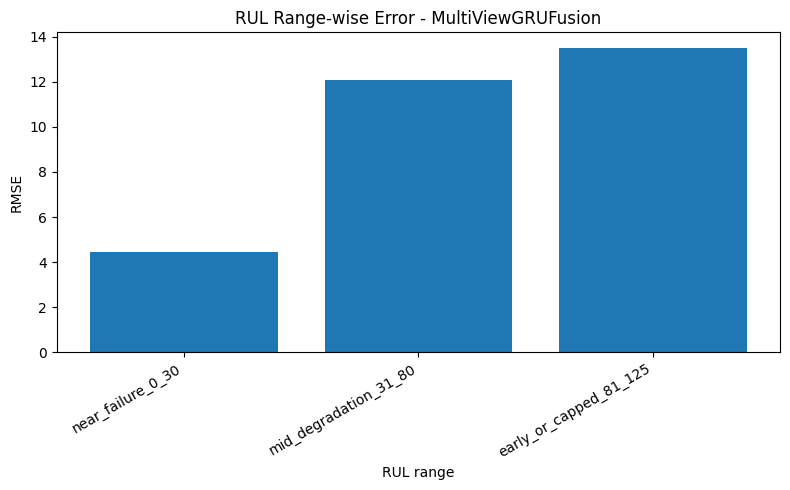

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range_metrics_df['rul_range'].astype(str), range_metrics_df['rmse'])
ax.set_ylabel('RMSE')
ax.set_xlabel('RUL range')
ax.set_title('RUL Range-wise Error - MultiViewGRUFusion')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/rul_range_error_multiview_fd001.png', dpi=300)
plt.show()


## 13. Prediction Bias Analysis

Prediction bias analysis summarizes whether the model tends to over-predict or under-predict RUL, and what fraction of predictions fall within selected error bands.

In [18]:
bias_summary = pd.DataFrame([{
    'condition':               'baseline',
    'mean_error':              baseline_metrics['mean_error'],
    'median_error':            baseline_metrics['median_error'],
    'under_prediction_rate':   round(float((baseline_pred_df['error'] < 0).mean()), 4),
    'over_prediction_rate':    round(float((baseline_pred_df['error'] > 0).mean()), 4),
    'within_5_cycles_rate':    round(float((baseline_pred_df['abs_error'] <= 5).mean()), 4),
    'within_10_cycles_rate':   round(float((baseline_pred_df['abs_error'] <= 10).mean()), 4),
    'within_20_cycles_rate':   round(float((baseline_pred_df['abs_error'] <= 20).mean()), 4),
}])

bias_summary.to_csv(f'{ROBUST_DIR}/prediction_bias_summary_multiview_fd001.csv', index=False)
print(bias_summary.to_string(index=False))


condition  mean_error  median_error  under_prediction_rate  over_prediction_rate  within_5_cycles_rate  within_10_cycles_rate  within_20_cycles_rate
 baseline     -2.2779       -1.7065                 0.5648                0.4002                0.4002                 0.6432                 0.9046


## 14. Repeated Perturbation Stability

To avoid conclusions from a single random noise draw, each noise perturbation type is repeated five times with different random seeds. The mean and standard deviation of RMSE across repeats indicates prediction stability under that perturbation.

In [19]:
def repeated_noise_stability(model, X_seq, X_der, y_true, perturbation_type,
                              noise_std=0.1, repeats=5):
    records = []
    for i in range(repeats):
        seed = SEED + i
        if perturbation_type == 'sensor_sequence_noise':
            X_seq_p, X_der_p = add_gaussian_noise(X_seq, noise_std, seed=seed), X_der
        elif perturbation_type == 'derived_feature_noise':
            X_seq_p, X_der_p = X_seq, add_gaussian_noise(X_der, noise_std, seed=seed)
        elif perturbation_type == 'combined_noise':
            X_seq_p = add_gaussian_noise(X_seq, noise_std, seed=seed)
            X_der_p = add_gaussian_noise(X_der, noise_std, seed=seed + 100)
        else:
            raise ValueError(f'Unsupported perturbation type: {perturbation_type}')

        pred    = predict_fusion(model, X_seq_p, X_der_p)
        metrics = evaluate_predictions(y_true, pred)
        records.append({'repeat': i, 'perturbation_type': perturbation_type,
                        'noise_std': noise_std, **metrics})
    return pd.DataFrame(records)


In [20]:
stability_dfs = []
for perturbation_type in ['sensor_sequence_noise', 'derived_feature_noise', 'combined_noise']:
    stability_dfs.append(
        repeated_noise_stability(
            fusion_model, X_val_seq, X_val_der, y_val,
            perturbation_type, noise_std=0.1, repeats=5
        )
    )

stability_df = pd.concat(stability_dfs, ignore_index=True)
stability_df.to_csv(f'{ROBUST_DIR}/repeated_noise_stability_multiview_fd001.csv', index=False)

stability_summary_df = stability_df.groupby(
    ['perturbation_type', 'noise_std']
).agg(
    rmse_mean=('rmse', 'mean'),
    rmse_std=('rmse', 'std'),
    mae_mean=('mae', 'mean'),
    mae_std=('mae', 'std')
).reset_index()

stability_summary_df.to_csv(
    f'{ROBUST_DIR}/repeated_noise_stability_summary_multiview_fd001.csv', index=False
)
print(stability_summary_df.to_string(index=False))


    perturbation_type  noise_std  rmse_mean  rmse_std  mae_mean  mae_std
       combined_noise        0.1   12.22428  0.033890   9.00594 0.029134
derived_feature_noise        0.1   12.16010  0.026997   8.97754 0.036820
sensor_sequence_noise        0.1   12.07890  0.009210   8.94288 0.010824


## 15. MC Dropout Uncertainty (Optional)

The fusion model includes dropout layers. Running inference with `training=True` activates dropout at prediction time, producing stochastic outputs across repeated forward passes. This is used as an initial approximation of predictive uncertainty. It is not treated as a fully calibrated uncertainty estimate at this stage.

In [21]:
def mc_dropout_predict(model, X_seq, X_der, n_runs=30):
    preds = []
    for _ in range(n_runs):
        pred = model([X_seq, X_der], training=True).numpy().reshape(-1)
        preds.append(np.clip(pred, 0, 125))
    preds = np.vstack(preds)
    return preds.mean(axis=0), preds.std(axis=0)


In [22]:
mc_mean, mc_std = mc_dropout_predict(fusion_model, X_val_seq, X_val_der, n_runs=30)

mc_df                    = val_meta.copy()
mc_df['prediction_mean'] = mc_mean
mc_df['prediction_std']  = mc_std
mc_df['error']           = mc_df['prediction_mean'] - mc_df['RUL_capped']
mc_df['abs_error']       = mc_df['error'].abs()

mc_df.to_csv(f'{ROBUST_DIR}/mc_dropout_uncertainty_multiview_fd001.csv', index=False)

uncertainty_error_corr = mc_df[['prediction_std', 'abs_error']].corr().iloc[0, 1]

uncertainty_summary = pd.DataFrame([{
    'n_runs':                             30,
    'mean_prediction_std':                round(float(mc_df['prediction_std'].mean()), 4),
    'median_prediction_std':              round(float(mc_df['prediction_std'].median()), 4),
    'uncertainty_abs_error_correlation':  round(float(uncertainty_error_corr), 4),
}])

uncertainty_summary.to_csv(
    f'{ROBUST_DIR}/mc_dropout_uncertainty_summary_multiview_fd001.csv', index=False
)
print(uncertainty_summary.to_string(index=False))


 n_runs  mean_prediction_std  median_prediction_std  uncertainty_abs_error_correlation
     30               7.4738                 7.7246                             0.4875


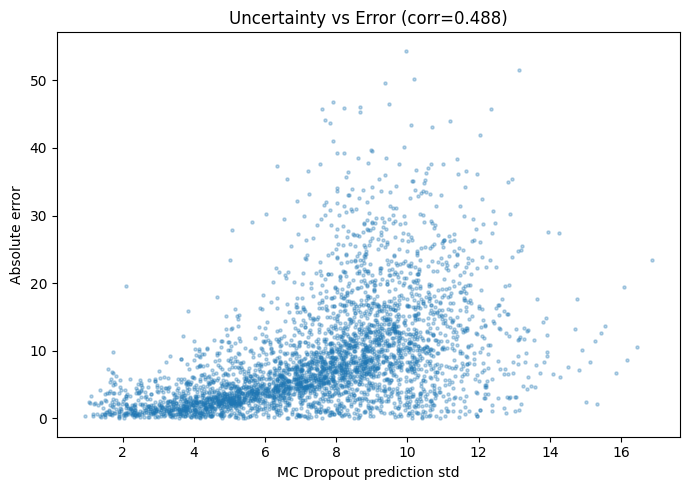

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(mc_df['prediction_std'], mc_df['abs_error'], alpha=0.3, s=5)
ax.set_xlabel('MC Dropout prediction std')
ax.set_ylabel('Absolute error')
ax.set_title(f'Uncertainty vs Error (corr={uncertainty_error_corr:.3f})')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/uncertainty_vs_error_multiview_fd001.png', dpi=300)
plt.show()


## 16. Robustness Interpretation

The robustness checks show that the MultiViewGRUFusion model is relatively stable under small controlled perturbations. Sensor sequence noise had very limited effect on validation RMSE, even at noise_std=0.20. Perturbations in the derived degradation feature view caused higher degradation than sensor sequence perturbations, which is consistent with the explainability analysis in Step 7 where the derived view was identified as the dominant contributor.

Random masking had a stronger effect than Gaussian noise, especially when derived degradation features were masked. At 30% derived-feature masking, RMSE increased substantially, and combined random masking produced the largest degradation among the partial masking conditions. Full derived-view masking caused the strongest performance collapse, confirming that the current fusion model depends heavily on the derived degradation view.

RUL range-wise analysis shows that near-failure predictions are the most accurate, while the early/capped RUL region has higher error and a stronger under-prediction tendency. This is important because near-failure predictions are operationally more critical in predictive maintenance.

MC Dropout produced a moderate correlation between prediction uncertainty and absolute error. This suggests that uncertainty estimates provide an initial confidence signal, but they are not treated as calibrated uncertainty values at this stage.

Overall, these checks provide initial model-level trustworthiness evidence. They do not prove operational reliability or production readiness.

Range-wise RMSE and MAE are used mainly to compare error behaviour across lifecycle regions. R² within individual RUL bands is reported but interpreted cautiously.

## 17. Observations

1. The best multi-view model was evaluated under controlled robustness conditions.
2. Gaussian noise was added separately to the sensor sequence view, the derived degradation view, and both views together at three noise levels.
3. Random masking was used to simulate incomplete input values at three masking rates.
4. View masking results from the explainability analysis (Step 7) were included as missing-view robustness evidence.
5. RUL range-wise error analysis was performed to inspect model behaviour across near-failure, mid-degradation, and early/capped regions.
6. Error bias metrics were computed to check under-prediction and over-prediction tendency.
7. Repeated perturbation stability analysis was performed across five random seeds to assess variability.
8. MC Dropout was used as an initial approximation of predictive uncertainty.
9. These checks provide initial model-level trustworthiness evidence, but do not prove production reliability.

## 18. Generated Artefacts

In [24]:
print('Robustness CSVs:')
for f in sorted(os.listdir(ROBUST_DIR)):
    print(f'  {f}')

print('\nFigures:')
for f in sorted(os.listdir(FIG_DIR)):
    if any(k in f for k in ['robustness', 'rul_range', 'uncertainty']):
        print(f'  {f}')


Robustness CSVs:
  baseline_predictions_multiview_fd001.csv
  mc_dropout_uncertainty_multiview_fd001.csv
  mc_dropout_uncertainty_summary_multiview_fd001.csv
  prediction_bias_summary_multiview_fd001.csv
  repeated_noise_stability_multiview_fd001.csv
  repeated_noise_stability_summary_multiview_fd001.csv
  robustness_summary_multiview_fd001.csv
  rul_range_error_analysis_multiview_fd001.csv

Figures:
  robustness_summary_rmse_multiview_fd001.png
  rul_range_error_multiview_fd001.png
  uncertainty_vs_error_multiview_fd001.png
